<a href="https://colab.research.google.com/github/anjicx/ComorbidityNetworkGNN/blob/main/GRU_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-geometric

import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc,
)
from google.colab import drive
drive.mount('/content/drive')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


#LOADIG DATA


# adjacency matrices
adj_matrices = {}
for i in range(1, 9):
    path = f'/content/drive/MyDrive/Adj_Matrix_Age_ICD_Male/Adj_Matrix_Male_ICD_age_{i}.csv'
    adj_matrices[i] = pd.read_csv(path, sep=r"\s+", header=None, engine="python")

# ICD codes
icd_df = pd.read_csv('/content/drive/MyDrive/AdjacencyMatrices/ICD10_Diagnoses_All.csv')
icd_codes = icd_df['icd_code'].tolist()

# prevalence
prev_df = pd.read_csv('/content/drive/MyDrive/AdjacencyMatrices/Prevalence_Sex_Age_Year_ICD.csv')

male_prev = (
    prev_df[prev_df['sex'] == 'Male']
    .groupby(['Age_Group', 'icd_code'], as_index=False)['p']
    .mean()
)

age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79"]

prev_features = {}
for idx, age in enumerate(age_labels, 1):
    age_data = male_prev[male_prev['Age_Group'] == age].set_index('icd_code')['p']
    prev_vector = np.array([age_data.get(code, 0.0) for code in icd_codes], dtype=float)
    prev_features[idx] = prev_vector
    print(f"Age group {idx} ({age}): {(prev_vector > 0).sum()} diseases have prevalence")

# ICD block one-hot
block_map = {
    'A': 0, 'B': 0,
    'C': 1, 'D': 1,
    'E': 2,
    'F': 3,
    'G': 4,
    'H': 5,
    'I': 6,
    'J': 7,
    'K': 8,
    'L': 9,
    'M': 10,
    'N': 11,
    'O': 12,
    'P': 13,
    'Q': 14,
    'R': 15,
    'S': 16, 'T': 16,
    'V': 17, 'W': 17, 'X': 17, 'Y': 17,
    'Z': 18
}

num_blocks = max(block_map.values()) + 1
blocks = np.zeros((len(icd_codes), num_blocks), dtype=float)

for j, code in enumerate(icd_codes):
    first = code[0].upper()
    if first in block_map:
        blocks[j, block_map[first]] = 1.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.8 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda
Age group 1 (0-9): 883 diseases have prevalence
Age group 2 (10-19): 897 diseases have prevalence
Age group 3 (20-29): 929 diseases have prevalence
Age group 4 (30-39): 932 diseases have prevalence
Age group 5 (40-49): 953 diseases have prevalence
Age group 6 (50-59): 935 diseases have prevalence
Age group 7 (60-69): 925 diseases have prevalence
Age group 8 (70-79): 883 diseases have prevalence


In [3]:

NUM_AGES = 8
NUM_NODES = len(icd_codes)
print("NUM_NODES =", NUM_NODES)

NUM_NODES = 1080


In [4]:
def build_full_graphs(adj_matrices, prev_features, blocks, add_degree_feature=True):
    graphs = {}
    binary_adj = {}

    for age in range(1, NUM_AGES + 1):
        raw = adj_matrices[age].values.astype(float)

        adj_bin = (raw > 0).astype(np.int64)
        np.fill_diagonal(adj_bin, 0)
        adj_bin = np.maximum(adj_bin, adj_bin.T)
        binary_adj[age] = adj_bin

        rows, cols = np.where(
            (adj_bin > 0) &
            np.triu(np.ones_like(adj_bin, dtype=bool), k=1)
        )

        if len(rows) == 0:
            edge_index = torch.empty((2, 0), dtype=torch.long)
        else:
            edge_index = torch.tensor(
                np.vstack([
                    np.concatenate([rows, cols]),
                    np.concatenate([cols, rows])
                ]),
                dtype=torch.long
            )

        prev_vec = prev_features[age].reshape(-1, 1)
        x_parts = [prev_vec, blocks]

        if add_degree_feature:
            degree = adj_bin.sum(axis=1).reshape(-1, 1).astype(float)
            x_parts.append(degree)

        x = np.hstack(x_parts)

        graphs[age] = Data(
            x=torch.tensor(x, dtype=torch.float),
            edge_index=edge_index,
            num_nodes=NUM_NODES
        )

        print(
            f"Age {age}: x shape={graphs[age].x.shape}, "
            f"edges={edge_index.shape[1] // 2}"
        )

    return graphs, binary_adj

graphs, binary_adj = build_full_graphs(
    adj_matrices=adj_matrices,
    prev_features=prev_features,
    blocks=blocks,
    add_degree_feature=True
)

BASE_IN_CHANNELS = graphs[1].x.shape[1]
print("Base feature dim:", BASE_IN_CHANNELS)

Age 1: x shape=torch.Size([1080, 21]), edges=425
Age 2: x shape=torch.Size([1080, 21]), edges=120
Age 3: x shape=torch.Size([1080, 21]), edges=312
Age 4: x shape=torch.Size([1080, 21]), edges=631
Age 5: x shape=torch.Size([1080, 21]), edges=1489
Age 6: x shape=torch.Size([1080, 21]), edges=2456
Age 7: x shape=torch.Size([1080, 21]), edges=3224
Age 8: x shape=torch.Size([1080, 21]), edges=3663
Base feature dim: 21


In [5]:
class NodeFeatureGRU(nn.Module):
    def __init__(
        self,
        base_in_channels,
        num_nodes,
        id_emb_dim=16,
        gru_hidden=64,
        dropout=0.1,
    ):
        super().__init__()
        self.num_nodes = num_nodes

        self.node_id_emb = nn.Embedding(num_nodes, id_emb_dim)

        self.gru = nn.GRU(
            input_size=base_in_channels + id_emb_dim,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)
        self.next_node_proj = nn.Linear(gru_hidden, gru_hidden)

        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * gru_hidden, gru_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden, 1),
        )

    def build_history_tensor(self, history_graphs):
        seq_list = []
        node_ids = torch.arange(self.num_nodes, device=history_graphs[0].x.device)
        id_emb = self.node_id_emb(node_ids)

        for g in history_graphs:
            x_t = torch.cat([g.x, id_emb], dim=-1)
            seq_list.append(x_t)

        seq = torch.stack(seq_list, dim=1)
        return seq

    def predict_next_node_embeddings(self, history_graphs):
        seq = self.build_history_tensor(history_graphs)
        out, _ = self.gru(seq)
        last_out = out[:, -1, :]
        last_out = self.dropout(last_out)
        z_next = self.next_node_proj(last_out)
        return z_next

    def decode_edges(self, z_next, edge_label_index):
        src = z_next[edge_label_index[0]]
        dst = z_next[edge_label_index[1]]
        pair = torch.cat([src, dst], dim=-1)
        logits = self.edge_mlp(pair).squeeze(-1)
        return logits


class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)

        loss = alpha_t * (1 - pt).pow(self.gamma) * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

HELPERS

In [6]:
def clone_to_device_graph(graph, device):
    g = copy.copy(graph)
    g.x = graph.x.to(device)
    g.edge_index = graph.edge_index.to(device)
    return g

def move_history_to_device(history_graphs, device):
    return [clone_to_device_graph(g, device) for g in history_graphs]

def build_all_undirected_pairs(num_nodes, device):
    rows, cols = torch.triu_indices(num_nodes, num_nodes, offset=1, device=device)
    return torch.stack([rows, cols], dim=0)

def get_full_y_true_from_adj(adj_bin):
    rows, cols = np.triu_indices(adj_bin.shape[0], k=1)
    y_true = adj_bin[rows, cols].astype(np.int64)
    return y_true

def precision_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)[:k]
    return float(y_true[idx].mean()) if len(idx) > 0 else 0.0

def recall_at_k(y_true, y_score, k):
    idx = np.argsort(-y_score)[:k]
    tp_at_k = y_true[idx].sum()
    total_pos = y_true.sum()
    return float(tp_at_k / total_pos) if total_pos > 0 else 0.0

def f1_from_precision_recall(p, r):
    return float((2 * p * r) / (p + r)) if (p + r) > 0 else 0.0

def score_all_pairs(model, history_graphs, batch_size=50000):
    model.eval()
    with torch.no_grad():
        z_next = model.predict_next_node_embeddings(history_graphs)
        num_nodes = z_next.size(0)
        all_pairs = build_all_undirected_pairs(num_nodes, z_next.device)

        probs_all = []
        num_pairs = all_pairs.size(1)

        for start in range(0, num_pairs, batch_size):
            end = min(start + batch_size, num_pairs)
            pair_batch = all_pairs[:, start:end]
            logits = model.decode_edges(z_next, pair_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_all.append(probs)

        y_score = np.concatenate(probs_all)
        return all_pairs.cpu(), y_score

def evaluate_full_matrix(model, history_graphs, target_adj_bin, batch_size=50000):
    pair_index_cpu, y_score = score_all_pairs(model, history_graphs, batch_size=batch_size)
    y_true = get_full_y_true_from_adj(target_adj_bin)

    roc_auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)

    p100 = precision_at_k(y_true, y_score, 100)
    r100 = recall_at_k(y_true, y_score, 100)
    f100 = f1_from_precision_recall(p100, r100)

    p500 = precision_at_k(y_true, y_score, 500)
    r500 = recall_at_k(y_true, y_score, 500)
    f500 = f1_from_precision_recall(p500, r500)

    pos = int(y_true.sum())
    total = len(y_true)

    return {
        "num_pairs": total,
        "num_pos": pos,
        "num_neg": total - pos,
        "pos_rate": pos / total,
        "roc_auc": roc_auc,
        "ap": ap,
        "pr_auc": pr_auc,
        "ap_baseline": pos / total,
        "precision_at_100": p100,
        "recall_at_100": r100,
        "f1_at_100": f100,
        "precision_at_500": p500,
        "recall_at_500": r500,
        "f1_at_500": f500,
        "y_true": y_true,
        "y_score": y_score,
        "pair_index_cpu": pair_index_cpu,
    }

def build_prefix_tasks_upto(graphs, max_age):
    tasks = []
    for target_age in range(2, max_age + 1):
        history_graphs = [graphs[a] for a in range(1, target_age)]
        tasks.append({
            "target_age": target_age,
            "history": history_graphs,
            "target_graph": graphs[target_age],
        })
    return tasks

GRID

In [7]:
ACTIVE_PREFIXES = [4, 5, 7, 8]

GRU_HIDDEN_SIZES = [64, 128]

GRU_LOSS_CONFIGS = [
    {"loss_name": "weighted_bce_pw50", "loss_type": "weighted_bce", "pos_weight": 50.0},
    {"loss_name": "weighted_bce_pw60", "loss_type": "weighted_bce", "pos_weight": 60.0},
    {"loss_name": "focal_a075_g2", "loss_type": "focal", "alpha": 0.75, "gamma": 2.0},
    {"loss_name": "focal_a090_g2", "loss_type": "focal", "alpha": 0.90, "gamma": 2.0},
]

EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4
TRAIN_PAIR_BATCH_SIZE = 50000
ID_EMB_DIM = 16
DROPOUT = 0.1

In [8]:
def make_loss_from_config(loss_cfg, device):
    if loss_cfg["loss_type"] == "weighted_bce":
        pos_weight = torch.tensor([loss_cfg["pos_weight"]], dtype=torch.float, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss_info = {"effective_pos_weight": float(loss_cfg["pos_weight"])}
    elif loss_cfg["loss_type"] == "focal":
        criterion = BinaryFocalLoss(
            alpha=loss_cfg["alpha"],
            gamma=loss_cfg["gamma"],
            reduction="mean",
        )
        loss_info = {
            "effective_pos_weight": None,
            "alpha": loss_cfg["alpha"],
            "gamma": loss_cfg["gamma"],
        }
    else:
        raise ValueError(f"Unknown loss type: {loss_cfg['loss_type']}")
    return criterion, loss_info

EXPERIMENT RUNNING

In [10]:
def run_gru_prefix_experiment(
    gru_hidden,
    loss_cfg,
    max_age,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    train_pair_batch_size=50000,
):
    set_seed(42)

    tasks = build_prefix_tasks_upto(graphs, max_age)
#if u decide to add g3 no validation possible!!
    if max_age == 3:
        train_tasks = [t for t in tasks if t["target_age"] == 2]
        val_task = None
        test_task = [t for t in tasks if t["target_age"] == 3][0]
    else:
        train_tasks = [t for t in tasks if t["target_age"] <= max_age - 2]
        val_task = [t for t in tasks if t["target_age"] == max_age - 1][0]
        test_task = [t for t in tasks if t["target_age"] == max_age][0]

    print("\n" + "=" * 110)
    print(f"MODEL=GRU | HIDDEN={gru_hidden} | LOSS={loss_cfg['loss_name']} | PREFIX=G1..G{max_age}")
    print("Train target ages:", [t["target_age"] for t in train_tasks])
    if val_task is None:
        print("Val target age: Not possible")
    else:
        print("Val target age:", val_task["target_age"])
    print("Test target age:", test_task["target_age"])

    all_pairs_cpu = build_all_undirected_pairs(NUM_NODES, device="cpu")
    rows_np = all_pairs_cpu[0].numpy()
    cols_np = all_pairs_cpu[1].numpy()
    all_pairs = all_pairs_cpu.to(device)

    full_train_labels = {}
    for task in train_tasks:
        age = task["target_age"]
        y_full = binary_adj[age][rows_np, cols_np]
        full_train_labels[age] = torch.tensor(y_full, dtype=torch.float)

        pos = int(full_train_labels[age].sum().item())
        neg = int(full_train_labels[age].numel() - pos)
        print(f"Train target G{age}: positives={pos}, negatives={neg}, neg/pos={neg/max(pos,1):.2f}")

    model = NodeFeatureGRU(
        base_in_channels=BASE_IN_CHANNELS,
        num_nodes=NUM_NODES,
        id_emb_dim=ID_EMB_DIM,
        gru_hidden=gru_hidden,
        dropout=DROPOUT,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion, loss_info = make_loss_from_config(loss_cfg, device)
    print("Loss info:", loss_info)

    best_state = None
    best_val_ap = -1.0
    best_train_loss = float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0

        for task in train_tasks:
            target_age = task["target_age"]
            history_graphs = move_history_to_device(task["history"], device)
            y_full = full_train_labels[target_age].to(device)

            optimizer.zero_grad()
            z_next = model.predict_next_node_embeddings(history_graphs)

            num_pairs = all_pairs.size(1)
            total_loss_tensor = torch.tensor(0.0, device=device)
            n_batches = 0

            for start in range(0, num_pairs, train_pair_batch_size):
                end = min(start + train_pair_batch_size, num_pairs)
                pair_batch = all_pairs[:, start:end]
                y_batch = y_full[start:end]

                logits = model.decode_edges(z_next, pair_batch)
                loss_batch = criterion(logits, y_batch)

                total_loss_tensor = total_loss_tensor + loss_batch
                n_batches += 1

            loss = total_loss_tensor / n_batches
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        mean_train_loss = total_train_loss / len(train_tasks)

        if val_task is None:
            if mean_train_loss < best_train_loss:
                best_train_loss = mean_train_loss
                best_state = copy.deepcopy(model.state_dict())
        else:
            val_history = move_history_to_device(val_task["history"], device)
            val_metrics = evaluate_full_matrix(
                model=model,
                history_graphs=val_history,
                target_adj_bin=binary_adj[val_task["target_age"]],
                batch_size=50000,
            )
            if val_metrics["ap"] > best_val_ap:
                best_val_ap = val_metrics["ap"]
                best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0:
            if val_task is None:
                print(f"Epoch {epoch:03d} | train_loss={mean_train_loss:.4f}")
            else:
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={mean_train_loss:.4f} | "
                    f"VAL(G{val_task['target_age']}) AP={val_metrics['ap']:.4f} | "
                    f"PR-AUC={val_metrics['pr_auc']:.4f} | "
                    f"ROC-AUC={val_metrics['roc_auc']:.4f}"
                )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_history = move_history_to_device(test_task["history"], device)
    test_metrics = evaluate_full_matrix(
        model=model,
        history_graphs=test_history,
        target_adj_bin=binary_adj[test_task["target_age"]],
        batch_size=50000,
    )

    print(f"\nFINAL TEST | MODEL=GRU | HIDDEN={gru_hidden} | LOSS={loss_cfg['loss_name']} | TARGET=G{test_task['target_age']}")
    print(f"AP              : {test_metrics['ap']:.4f}")
    print(f"PR-AUC          : {test_metrics['pr_auc']:.4f}")
    print(f"Precision@100   : {test_metrics['precision_at_100']:.4f}")
    print(f"Recall@100      : {test_metrics['recall_at_100']:.4f}")
    print(f"F1@100          : {test_metrics['f1_at_100']:.4f}")
    print(f"Precision@500   : {test_metrics['precision_at_500']:.4f}")
    print(f"Recall@500      : {test_metrics['recall_at_500']:.4f}")
    print(f"F1@500          : {test_metrics['f1_at_500']:.4f}")

    result = {
        "model": "GRU",
        "gru_hidden": gru_hidden,
        "loss_name": loss_cfg["loss_name"],
        "loss_type": loss_cfg["loss_type"],
        "test_target": test_task["target_age"],
        "group": f"G{test_task['target_age']}",
        "test_ap": test_metrics["ap"],
        "test_pr_auc": test_metrics["pr_auc"],
        "test_precision_at_100": test_metrics["precision_at_100"],
        "test_recall_at_100": test_metrics["recall_at_100"],
        "test_f1_at_100": test_metrics["f1_at_100"],
        "test_precision_at_500": test_metrics["precision_at_500"],
        "test_recall_at_500": test_metrics["recall_at_500"],
        "test_f1_at_500": test_metrics["f1_at_500"],
    }

    if loss_cfg["loss_type"] == "weighted_bce":
        result["pos_weight"] = loss_cfg["pos_weight"]
        result["alpha"] = None
        result["gamma"] = None
    else:
        result["pos_weight"] = None
        result["alpha"] = loss_cfg["alpha"]
        result["gamma"] = loss_cfg["gamma"]

    return result

In [11]:
gru_results = []

for gru_hidden in GRU_HIDDEN_SIZES:
    for loss_cfg in GRU_LOSS_CONFIGS:
        for max_age in ACTIVE_PREFIXES:
            print(f"RUNNING: hidden={gru_hidden}, loss={loss_cfg['loss_name']}, prefix=G1..G{max_age}")
            result = run_gru_prefix_experiment(
                gru_hidden=gru_hidden,
                loss_cfg=loss_cfg,
                max_age=max_age,
                epochs=EPOCHS,
                lr=LR,
                weight_decay=WEIGHT_DECAY,
                train_pair_batch_size=TRAIN_PAIR_BATCH_SIZE,
            )
            gru_results.append(result)

            temp_df = pd.DataFrame(gru_results)
            temp_df.to_csv("/content/drive/MyDrive/gru_only_grid_checkpoint.csv", index=False)
            print("Checkpoint saved to Drive.")

gru_results_df = pd.DataFrame(gru_results)
gru_results_df

RUNNING: hidden=64, loss=weighted_bce_pw50, prefix=G1..G4

MODEL=GRU | HIDDEN=64 | LOSS=weighted_bce_pw50 | PREFIX=G1..G4
Train target ages: [2]
Val target age: 3
Test target age: 4
Train target G2: positives=120, negatives=582540, neg/pos=4854.50
Loss info: {'effective_pos_weight': 50.0}
Epoch 001 | train_loss=0.6747 | VAL(G3) AP=0.0011 | PR-AUC=0.0010 | ROC-AUC=0.6459
Epoch 010 | train_loss=0.5580 | VAL(G3) AP=0.0005 | PR-AUC=0.0005 | ROC-AUC=0.3984
Epoch 020 | train_loss=0.3535 | VAL(G3) AP=0.0003 | PR-AUC=0.0003 | ROC-AUC=0.2442
Epoch 030 | train_loss=0.1320 | VAL(G3) AP=0.0003 | PR-AUC=0.0003 | ROC-AUC=0.1784
Epoch 040 | train_loss=0.0709 | VAL(G3) AP=0.0003 | PR-AUC=0.0003 | ROC-AUC=0.1809
Epoch 050 | train_loss=0.0621 | VAL(G3) AP=0.0006 | PR-AUC=0.0005 | ROC-AUC=0.4763
Epoch 060 | train_loss=0.0474 | VAL(G3) AP=0.0270 | PR-AUC=0.0262 | ROC-AUC=0.7572
Epoch 070 | train_loss=0.0451 | VAL(G3) AP=0.0349 | PR-AUC=0.0337 | ROC-AUC=0.8055
Epoch 080 | train_loss=0.0409 | VAL(G3) AP=0.0

,model,gru_hidden,loss_name,loss_type,test_target,group,test_ap,test_pr_auc,test_precision_at_100,test_recall_at_100,test_f1_at_100,test_precision_at_500,test_recall_at_500,test_f1_at_500,pos_weight,alpha,gamma
0,GRU,64,weighted_bce_pw50,weighted_bce,4,G4,0.092396,0.092084,0.43,0.068146,0.117647,0.162,0.128368,0.143236,50.0,NaN,NaN
1,GRU,64,weighted_bce_pw50,weighted_bce,5,G5,0.087148,0.086730,0.36,0.024177,0.045312,0.244,0.081934,0.122675,50.0,NaN,NaN
2,GRU,64,weighted_bce_pw50,weighted_bce,7,G7,0.532935,0.532832,0.92,0.028536,0.055355,0.808,0.125310,0.216971,50.0,NaN,NaN
3,GRU,64,weighted_bce_pw50,weighted_bce,8,G8,0.586894,0.586806,0.87,0.023751,0.046240,0.830,0.113295,0.199375,50.0,NaN,NaN
4,GRU,64,weighted_bce_pw60,weighted_bce,4,G4,0.096521,0.096165,0.44,0.069731,0.120383,0.174,0.137876,0.153846,60.0,NaN,NaN
5,GRU,64,weighted_bce_pw60,weighted_bce,5,G5,0.099247,0.098604,0.42,0.028207,0.052863,0.284,0.095366,0.142785,60.0,NaN,NaN
6,GRU,64,weighted_bce_pw60,weighted_bce,7,G7,0.532213,0.532104,0.90,0.027916,0.054152,0.808,0.125310,0.216971,60.0,NaN,NaN
7,GRU,64,weighted_bce_pw60,weighted_bce,8,G8,0.583734,0.583646,0.87,0.023751,0.046240,0.840,0.114660,0.201778,60.0,NaN,NaN
8,GRU,64,focal_a075_g2,focal,4,G4,0.069557,0.069308,0.36,0.057052,0.098495,0.120,0.095087,0.106101,NaN,0.75,2.0
9,GRU,64,focal_a075_g2,focal,5,G5,0.083549,0.083105,0.44,0.029550,0.055381,0.228,0.076561,0.114630,NaN,0.75,2.0


SAVE RESULT FOR FUTURE

In [12]:
gru_results_df.to_csv("/content/drive/MyDrive/gru_only_grid_results.csv", index=False)
print("Saved to /content/drive/MyDrive/gru_only_grid_results.csv")

Saved to /content/drive/MyDrive/gru_only_grid_results.csv


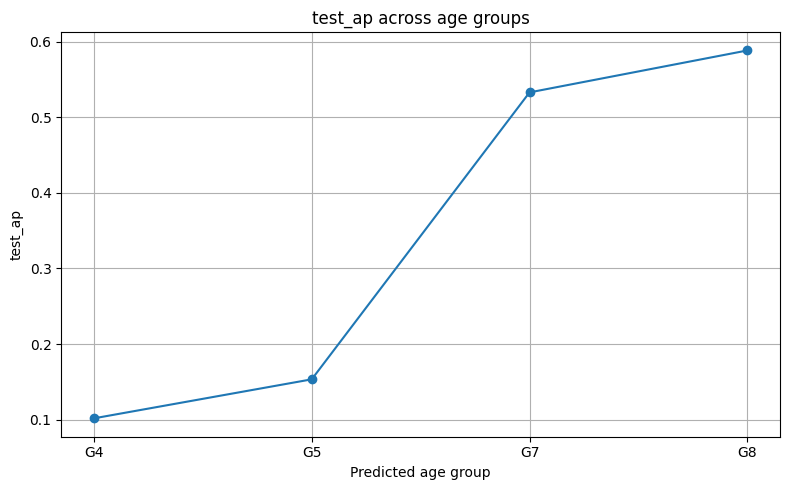

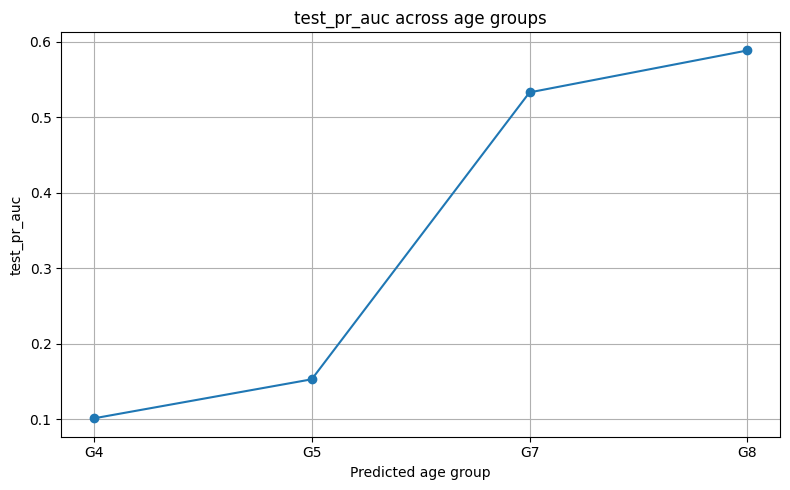

In [19]:
plot_df = best_gru_by_ap.sort_values("test_target").copy()

if "group" not in plot_df.columns:
    plot_df["group"] = "G" + plot_df["test_target"].astype(str)

metrics = [
    "test_ap",
    "test_pr_auc"
]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.plot(plot_df["group"], plot_df[metric], marker="o")
    plt.xlabel("Predicted age group")
    plt.ylabel(metric)
    plt.title(f"{metric} across age groups")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

BEST CONFIGURATION RESULT

In [21]:
show_df = best_gru_by_ap.copy()

show_df["config"] = np.where(
    show_df["loss_name"].str.startswith("weighted_bce"),
    "weighted BCE (pos_weight=" + show_df["pos_weight"].astype(str) + ")",
    "focal loss (alpha=" + show_df["alpha"].astype(str) + ", gamma=" + show_df["gamma"].astype(str) + ")"
)

show_df[[
    "group",
    "gru_hidden",
    "config",
    "test_ap",
    "test_pr_auc",
    "test_precision_at_100",
    "test_recall_at_100",
    "test_f1_at_100",
    "test_precision_at_500",
    "test_recall_at_500",
    "test_f1_at_500",
]].round(4)

,group,gru_hidden,config,test_ap,test_pr_auc,test_precision_at_100,test_recall_at_100,test_f1_at_100,test_precision_at_500,test_recall_at_500,test_f1_at_500
0,G4,128,"focal loss (alpha=0.9, gamma=2.0)",0.1018,0.1014,0.48,0.0761,0.1313,0.178,0.1410,0.1574
1,G5,128,"focal loss (alpha=0.9, gamma=2.0)",0.1534,0.1531,0.65,0.0437,0.0818,0.388,0.1303,0.1951
2,G7,64,weighted BCE (pos_weight=50.0),0.5329,0.5328,0.92,0.0285,0.0554,0.808,0.1253,0.2170
3,G8,128,weighted BCE (pos_weight=50.0),0.5884,0.5883,0.94,0.0257,0.0500,0.882,0.1204,0.2119
